# Caderno 03: Engenharia de Features

**Objetivo:** Derivar todas as variáveis analíticas necessárias para responder às quatro perguntas de pesquisa.

**Padrão Empírico ACM SIGSOFT (Data Science):**
- *Describes the feature engineering approaches and transformations that were applied;*
- *Justifies all statistics and (automated or manual) heuristics used;*
- *Manually inspects some non-trivial portion of the data (data sanity checks).*

---

## Mapa de Features → Perguntas de Pesquisa

| Grupo | Features | RQ Respondida |
|---|---|---|
| Temporais | `periodo_ano_mes`, `trimestre`, `semestre`, `ano_eleitoral`, `is_fim_de_semana`, `periodo_pandemia` | RQ4 |
| Por Senador | `gasto_total_senador`, `gasto_medio_mensal_senador`, `n_fornecedores_distintos`, `n_categorias_distintas`, `proporcao_maior_categoria`, `proporcao_fds_por_senador`, `proporcao_fim_mes_senador`, `proporcao_maior_fornecedor` | RQ2 |
| Por Categoria | `gasto_total_categoria`, `percentual_categoria_global`, `rank_categoria` | RQ1 |
| Anomalias | `valor_log1p`, `zscore_categoria`, `iqr_outlier_flag`, `primeiro_digito`, `anomalia_consenso` | RQ3 |

In [1]:
import pandas as pd
import sqlite3
import json
import sys
import numpy as np
from pathlib import Path

ROOT_DIR      = Path().resolve().parent
DB_PATH       = ROOT_DIR / 'database' / 'ceap.db'
PROCESSED_DIR = ROOT_DIR / 'data' / 'processed'
LOGS_DIR      = ROOT_DIR / 'logs'
sys.path.append(str(ROOT_DIR))

from src.features import (
    engenharia_de_features,
    INVENTARIO_FEATURES,
    FEATURES_CLUSTERING_SENADOR,
)

print(f"Conectando ao banco: {DB_PATH}")
conn = sqlite3.connect(DB_PATH)

df_fato = pd.read_sql(
    "SELECT * FROM fato_despesa",
    conn,
    parse_dates=['data_despesa']
)
# Restaura tipos inteiros anuláveis após leitura do SQLite
for col in ['ano', 'mes', 'cod_senador']:
    df_fato[col] = pd.to_numeric(df_fato[col], errors='coerce').astype('Int64')

print(f"Registros carregados de fato_despesa: {len(df_fato):,}")
print(f"Colunas disponíveis: {list(df_fato.columns)}")

Conectando ao banco: C:\Users\olive\OneDrive\Documentos\UnB\CE\Artigo\ceap-56-legislatura\database\ceap.db
Registros carregados de fato_despesa: 88,111
Colunas disponíveis: ['ano', 'mes', 'cod_senador', 'nome_senador_limpo', 'tipo_despesa_limpo', 'nome_fornecedor_limpo', 'documento_fornecedor', 'data_despesa', 'valor_limpo', 'tipo_documento_limpo', 'detalhamento_limpo', 'source_file']


---
## 3.1 Execução do Pipeline de Features

O módulo `src/features.py` centraliza toda a lógica de derivação. A ordem de execução importa: features **temporais** são pré-requisito para as features de **senador** (que dependem de `periodo_ano_mes` e `is_fim_de_semana`).

In [2]:
df_features = engenharia_de_features(df_fato)

print(f"Pipeline concluído.")
print(f"Registros: {len(df_features):,}")
print(f"Colunas originais: {df_fato.shape[1]}")
print(f"Colunas após features: {df_features.shape[1]}")
print(f"Novas features: {df_features.shape[1] - df_fato.shape[1]}")

[1/4] Features temporais.
[2/4] Features por senador.
[3/4] Features por categoria.
[4/4] Features de anomalia.
Pipeline concluído.
Registros: 88,111
Colunas originais: 12
Colunas após features: 34
Novas features: 22


---
## 3.2 Verificação de Sanidade (Data Sanity Checks)

**Padrão ACM SIGSOFT:** *'manually inspects some non-trivial portion of the data (data sanity checks)'*

Validamos cada grupo de features contra invariantes esperados.

In [3]:
erros = []
avisos = []

def check(condicao: bool, descricao: str, critico: bool = True):
    status = "Tudo certo!" if condicao else ("ERRO" if critico else "AVISO")
    print(f"{status}  {descricao}")
    if not condicao:
        (erros if critico else avisos).append(descricao)

print("SANITY CHECKS — FEATURES TEMPORAIS")
check(df_features['trimestre'].dropna().between(1, 4).all(),
      "Trimestre no intervalo [1,4]")
check(df_features['semestre'].isin([1, 2]).all(),
      "Semestre é 1 ou 2")
check(df_features['periodo_pandemia'].dropna().isin(
          ['pre_pandemia', 'pandemia', 'pos_pandemia']).all(),
      "periodo_pandemia tem apenas os 3 rótulos esperados")
check(df_features['is_fim_de_semana'].dropna().isin([True, False]).all(),
      "is_fim_de_semana é booleano")
pct_fds = df_features['is_fim_de_semana'].mean() * 100
check(3 <= pct_fds <= 30, #Veriricar mais tarde qual o intervalo realista, 3-30% é um chute inicial 
      f"Proporção de FDS razoável: {pct_fds:.1f}% (esperado 3%–30%)")

print()
print("SANITY CHECKS — FEATURES POR SENADOR")
check((df_features['gasto_total_senador'] > 0).all(),
      "gasto_total_senador > 0 para todos os registros")
check(df_features['proporcao_maior_categoria'].dropna().between(0, 1).all(),
      "proporcao_maior_categoria em [0,1]")
check(df_features['proporcao_fds_por_senador'].dropna().between(0, 1).all(),
      "proporcao_fds_por_senador em [0,1]")
check(df_features['proporcao_fim_mes_senador'].dropna().between(0, 1).all(),
      "proporcao_fim_mes_senador em [0,1]")
check(df_features['proporcao_maior_fornecedor'].dropna().between(0, 1).all(),
      "proporcao_maior_fornecedor em [0,1]")

# Verifica consistência: gasto_total_senador deve bater com a soma direta
soma_direta = df_features.groupby('cod_senador')['valor_limpo'].sum()
soma_feature = df_features.groupby('cod_senador')['gasto_total_senador'].first()
discrepancia = (soma_direta - soma_feature).abs().max()
check(discrepancia < 0.01,
      f"gasto_total_senador consistente com soma direta (max_diff={discrepancia:.4f})")

print()
print("SANITY CHECKS — FEATURES DE ANOMALIA")
check((df_features['valor_log1p'] >= 0).all(),
      "valor_log1p >= 0")
check(df_features['primeiro_digito'].between(1, 9).all(),
      "primeiro_digito em [1,9]")
check(df_features['iqr_outlier_flag'].dtype == bool or
      df_features['iqr_outlier_flag'].isin([True, False]).all(),
      "iqr_outlier_flag é booleano")
check(df_features['anomalia_consenso'].isin([True, False]).all(),
      "anomalia_consenso é booleano")
# anomalia_consenso deve ser subconjunto de iqr_outlier_flag
consenso_sem_iqr = (df_features['anomalia_consenso'] & ~df_features['iqr_outlier_flag']).sum()
check(consenso_sem_iqr == 0,
      "anomalia_consenso é subconjunto de iqr_outlier_flag")

print()
if erros:
    print(f"RESULTADO: {len(erros)} ERRO(S) CRÍTICO(S) — revisar src/features.py")
    for e in erros:
        print(f"  ✗ {e}")
else:
    print(f"RESULTADO: Todos os checks passaram. {len(avisos)} aviso(s).")

SANITY CHECKS — FEATURES TEMPORAIS
Tudo certo!  Trimestre no intervalo [1,4]
Tudo certo!  Semestre é 1 ou 2
Tudo certo!  periodo_pandemia tem apenas os 3 rótulos esperados
Tudo certo!  is_fim_de_semana é booleano
Tudo certo!  Proporção de FDS razoável: 11.6% (esperado 3%–30%)

SANITY CHECKS — FEATURES POR SENADOR
Tudo certo!  gasto_total_senador > 0 para todos os registros
Tudo certo!  proporcao_maior_categoria em [0,1]
Tudo certo!  proporcao_fds_por_senador em [0,1]
Tudo certo!  proporcao_fim_mes_senador em [0,1]
Tudo certo!  proporcao_maior_fornecedor em [0,1]
Tudo certo!  gasto_total_senador consistente com soma direta (max_diff=0.0000)

SANITY CHECKS — FEATURES DE ANOMALIA
Tudo certo!  valor_log1p >= 0
Tudo certo!  primeiro_digito em [1,9]
Tudo certo!  iqr_outlier_flag é booleano
Tudo certo!  anomalia_consenso é booleano
Tudo certo!  anomalia_consenso é subconjunto de iqr_outlier_flag

RESULTADO: Todos os checks passaram. 0 aviso(s).


---
## 3.3 Distribuição das Features por Senador

Estatísticas descritivas do conjunto de features que será usado no clustering (RQ2). 

**ACM SIGSOFT:** inclui medidas de variação (desvio-padrão, IQR), não apenas médias.

In [4]:
# Agrega uma linha por senador para análise do espaço de features
df_perfil_senador = (
    df_features
    .groupby('cod_senador')[FEATURES_CLUSTERING_SENADOR]
    .first()
    .reset_index()
)

print(f"Senadores únicos: {len(df_perfil_senador)}")
print()

stats = df_perfil_senador[FEATURES_CLUSTERING_SENADOR].describe(
    percentiles=[0.25, 0.5, 0.75]
).T
stats['IQR']       = stats['75%'] - stats['25%']
stats['cv']        = (stats['std'] / stats['mean']).round(3)
stats['skewness']  = df_perfil_senador[FEATURES_CLUSTERING_SENADOR].skew().round(3)

pd.set_option('display.float_format', '{:,.4f}'.format)
print("Estatísticas descritivas das features de senador (1 linha = 1 senador):")
display(stats[['count', 'mean', 'std', 'IQR', 'cv', 'skewness', 'min', '50%', 'max']])

Senadores únicos: 176

Estatísticas descritivas das features de senador (1 linha = 1 senador):


,count,mean,std,IQR,cv,skewness,min,50%,max
gasto_total_senador,176.0000,"722,112.3655","755,137.0011","1,389,788.1550",1.0460,0.7180,214.2900,"412,114.8700","2,467,717.6800"
gasto_medio_mensal_senador,176.0000,"22,532.9562","10,703.8855","17,549.0108",0.4750,-0.1210,214.2900,"22,128.1404","44,956.8555"
n_fornecedores_distintos,176.0000,68.8864,94.4062,84.0000,1.3700,2.6840,1.0000,34.0000,593.0000
n_categorias_distintas,176.0000,4.9091,1.5167,2.0000,0.3090,-0.6990,1.0000,5.0000,7.0000
proporcao_maior_categoria,176.0000,0.4979,0.1791,0.2417,0.3600,0.9350,0.2274,0.4573,1.0000
proporcao_fds_por_senador,176.0000,0.0977,0.0636,0.0672,0.6510,1.0640,0.0000,0.0906,0.4286
proporcao_fim_mes_senador,176.0000,0.2370,0.1683,0.1888,0.7100,1.2400,0.0000,0.1995,0.9782
proporcao_maior_fornecedor,176.0000,0.3645,0.1988,0.2085,0.5450,1.4290,0.0924,0.3088,1.0000


---
## 3.4 Verificação da Lei de Benford

Comparamos a distribuição observada do `primeiro_digito` contra a distribuição teórica de Benford P(d) = log₁₀(1 + 1/d). Esta análise responde **RQ3** de forma descritiva e serve de referência para a etapa de modelagem de anomalias.

**Limitação metodológica declarada:** desvio de Benford é condição necessária, não suficiente, para indicar irregularidade. Será tratado como feature de entrada no modelo, não como conclusão isolada.

Comparação: Distribuição Observada vs. Lei de Benford


,freq_observada,prop_observada,prop_benford,desvio_absoluto
digito,,,,
1,"31,401",0.3564,0.3010,0.0554
2,"19,641",0.2229,0.1761,0.0468
3,"10,507",0.1192,0.1249,0.0057
4,"6,626",0.0752,0.0969,0.0217
5,"5,963",0.0677,0.0792,0.0115
6,"4,496",0.0510,0.0669,0.0159
7,"3,554",0.0403,0.0580,0.0177
8,"3,206",0.0364,0.0512,0.0148
9,"2,717",0.0308,0.0458,0.0149



Teste qui-quadrado de ajuste à Lei de Benford:
  χ² = 4203.8474 | gl = 8 | p = 0.000000
  → A distribuição observada DIFERE significativamente de Benford (p < 0.05).
  → Interpretação: este resultado justifica o uso do primeiro_digito como
    feature de anomalia no modelo. Não implica fraude per se.


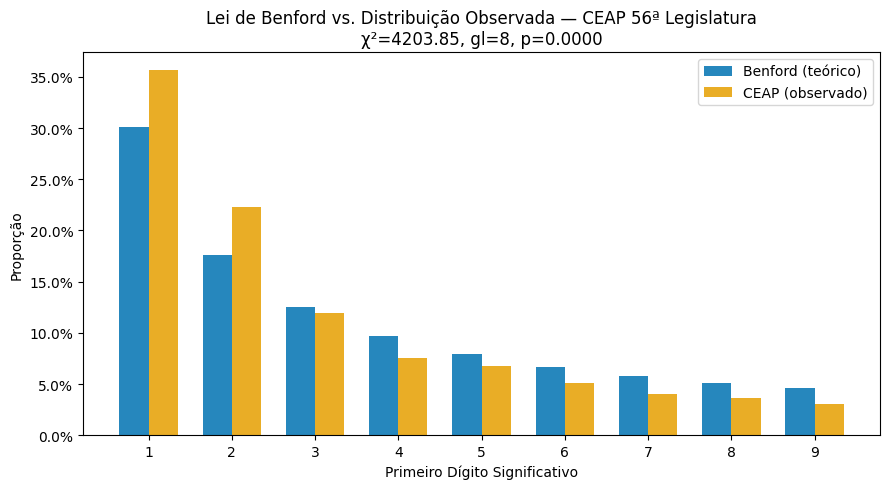

Figura salva em: C:\Users\olive\OneDrive\Documentos\UnB\CE\Artigo\ceap-56-legislatura\figures\fe_benford.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import chi2_contingency

# Distribuição teórica de Benford
digitos = list(range(1, 10))
benford_esperado = {d: np.log10(1 + 1/d) for d in digitos}

# Distribuição observada
obs_counts = df_features['primeiro_digito'].value_counts().sort_index()
obs_counts = obs_counts[obs_counts.index.isin(digitos)]
total = obs_counts.sum()
obs_prop = obs_counts / total

# Tabela comparativa
df_benford = pd.DataFrame({
    'digito'            : digitos,
    'freq_observada'    : [obs_counts.get(d, 0) for d in digitos],
    'prop_observada'    : [obs_prop.get(d, 0) for d in digitos],
    'prop_benford'      : [benford_esperado[d] for d in digitos],
})
df_benford['desvio_absoluto'] = (
    (df_benford['prop_observada'] - df_benford['prop_benford']).abs()
).round(4)

print("Comparação: Distribuição Observada vs. Lei de Benford")
display(df_benford.set_index('digito').style.format({
    'freq_observada': '{:,.0f}',
    'prop_observada': '{:.4f}',
    'prop_benford'  : '{:.4f}',
    'desvio_absoluto': '{:.4f}',
}))

# Teste qui-quadrado de ajuste
freq_obs      = np.array([obs_counts.get(d, 0) for d in digitos], dtype=float)
freq_esperada = np.array([benford_esperado[d] * total for d in digitos])
chi2 = np.sum((freq_obs - freq_esperada)**2 / freq_esperada)
from scipy.stats import chi2 as chi2_dist
p_valor = chi2_dist.sf(chi2, df=len(digitos) - 1)

print(f"\nTeste qui-quadrado de ajuste à Lei de Benford:")
print(f"  χ² = {chi2:.4f} | gl = {len(digitos)-1} | p = {p_valor:.6f}")
if p_valor < 0.05:
    print("  → A distribuição observada DIFERE significativamente de Benford (p < 0.05).")
    print("  → Interpretação: este resultado justifica o uso do primeiro_digito como")
    print("    feature de anomalia no modelo. Não implica fraude per se.")
else:
    print("  → A distribuição observada NÃO difere significativamente de Benford.")
    print("  → A feature primeiro_digito terá poder discriminativo limitado.")

# Visualização
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(digitos))
w = 0.35
ax.bar(x - w/2, df_benford['prop_benford'],  w, label='Benford (teórico)', color='#0072B2', alpha=0.85)
ax.bar(x + w/2, df_benford['prop_observada'], w, label='CEAP (observado)',  color='#E69F00', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(digitos)
ax.set_xlabel('Primeiro Dígito Significativo')
ax.set_ylabel('Proporção')
ax.set_title(
    f'Lei de Benford vs. Distribuição Observada — CEAP 56ª Legislatura\n'
    f'χ²={chi2:.2f}, gl={len(digitos)-1}, p={p_valor:.4f}'
)
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
fig.tight_layout()

figures_dir = ROOT_DIR / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figures_dir / 'fe_benford.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura salva em: {figures_dir / 'fe_benford.png'}")

---
## 3.5 Distribuição das Features Comportamentais de Senador

Visualizamos `proporcao_fds_por_senador`, `proporcao_fim_mes_senador` e `proporcao_maior_fornecedor` para verificar se há variância suficiente para discriminar senadores no clustering (RQ2).

Uma feature com variância próxima de zero não contribui para a separação de clusters.

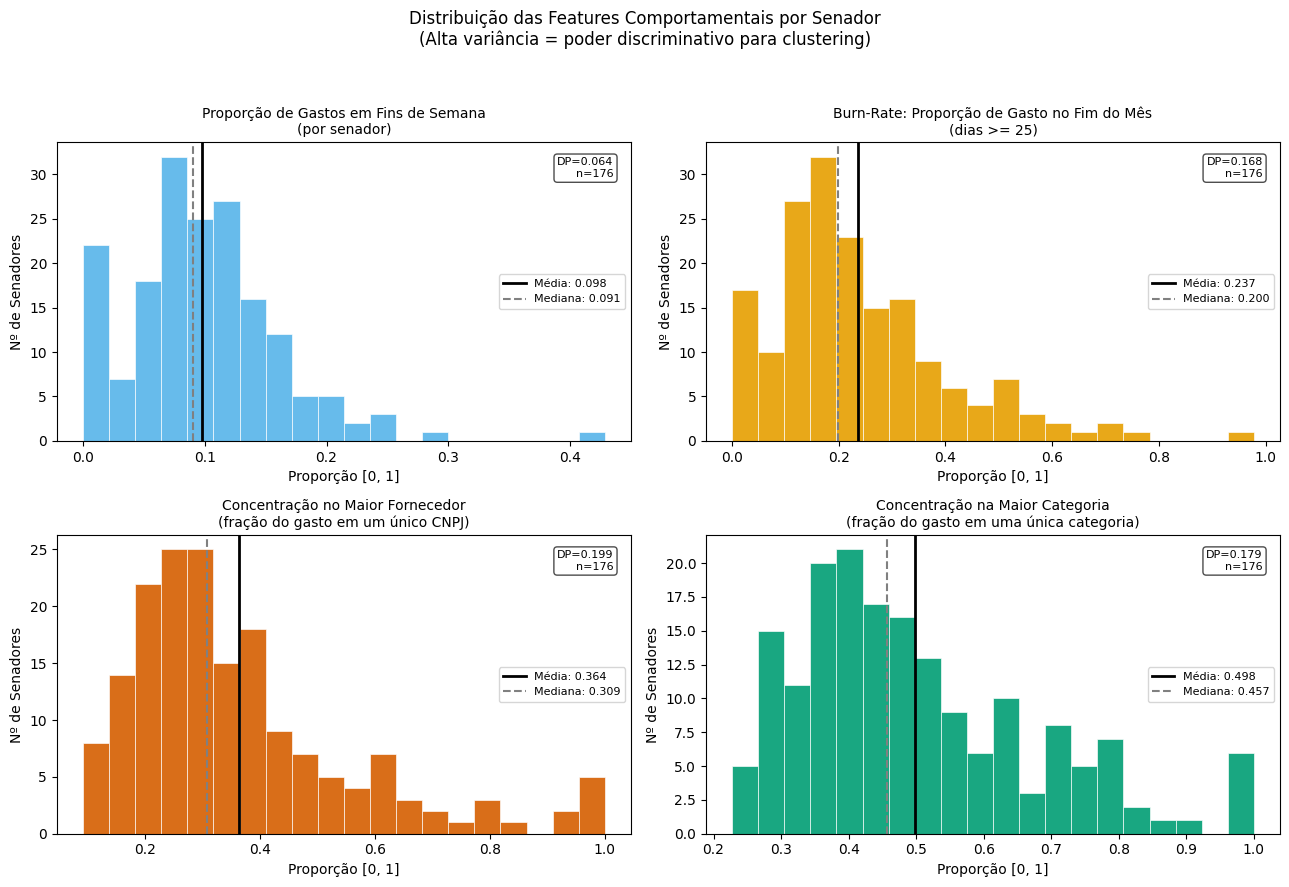

In [6]:
features_comportamentais = [
    'proporcao_fds_por_senador',
    'proporcao_fim_mes_senador',
    'proporcao_maior_fornecedor',
    'proporcao_maior_categoria',
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

titulos = [
    'Proporção de Gastos em Fins de Semana\n(por senador)',
    'Burn-Rate: Proporção de Gasto no Fim do Mês\n(dias >= 25)', #reavaliar
    'Concentração no Maior Fornecedor\n(fração do gasto em um único CNPJ)',
    'Concentração na Maior Categoria\n(fração do gasto em uma única categoria)',
]

PALETA = ['#56B4E9', '#E69F00', '#D55E00', '#009E73']

for ax, feat, titulo, cor in zip(axes, features_comportamentais, titulos, PALETA):
    serie = df_perfil_senador[feat].dropna()
    ax.hist(serie, bins=20, color=cor, edgecolor='white', linewidth=0.5, alpha=0.9)
    ax.axvline(serie.mean(),   color='black',  lw=2,   linestyle='-',  label=f'Média: {serie.mean():.3f}')
    ax.axvline(serie.median(), color='grey',   lw=1.5, linestyle='--', label=f'Mediana: {serie.median():.3f}')
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('Proporção [0, 1]')
    ax.set_ylabel('Nº de Senadores')
    ax.legend(fontsize=8)
    # Desvio-padrão como anotação
    ax.text(0.97, 0.95, f'DP={serie.std():.3f}\nn={serie.count()}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

fig.suptitle(
    'Distribuição das Features Comportamentais por Senador\n'
    '(Alta variância = poder discriminativo para clustering)',
    fontsize=12
)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(figures_dir / 'fe_comportamentais.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3.6 Análise de Cobertura e Valores Ausentes

Documentamos a cobertura de cada feature derivada para o relatório de qualidade.

In [7]:
todas_features = (
    INVENTARIO_FEATURES['temporais'] +
    INVENTARIO_FEATURES['por_senador'] +
    INVENTARIO_FEATURES['por_categoria'] +
    INVENTARIO_FEATURES['anomalia']
)

cobertura = []
for feat in todas_features:
    if feat in df_features.columns:
        n_null  = df_features[feat].isna().sum()
        pct_ok  = (1 - n_null / len(df_features)) * 100
        cobertura.append({
            'feature'      : feat,
            'n_nulos'      : int(n_null),
            'cobertura_pct': round(pct_ok, 2),
            'dtype'        : str(df_features[feat].dtype),
        })
    else:
        cobertura.append({'feature': feat, 'n_nulos': -1, 'cobertura_pct': 0.0, 'dtype': 'AUSENTE'})

df_cobertura = pd.DataFrame(cobertura)
print("Relatório de cobertura das features derivadas:")
display(df_cobertura.style.background_gradient(
    subset=['cobertura_pct'], cmap='RdYlGn', vmin=90, vmax=100
))

Relatório de cobertura das features derivadas:


,feature,n_nulos,cobertura_pct,dtype
0,periodo_ano_mes,0,100.000000,object
1,trimestre,0,100.000000,Int64
2,semestre,0,100.000000,int64
3,ano_eleitoral,0,100.000000,boolean
4,is_fim_de_semana,0,100.000000,bool
5,periodo_pandemia,3,100.000000,category
6,gasto_total_senador,0,100.000000,float64
7,gasto_medio_mensal_senador,0,100.000000,float64
8,n_fornecedores_distintos,0,100.000000,int64
9,n_categorias_distintas,0,100.000000,int64


---
## 3.7 Persistência

O DataFrame com features é salvo em duas formas:
1. **Tabela `features_ceap` no SQLite** — para consultas ad hoc e notebooks posteriores.
2. **CSV** em `data/processed/` — para portabilidade do pacote de replicação.

In [8]:
# Colunas com tipos problemáticos para SQLite precisam de conversão
df_para_salvar = df_features.copy()

# Period e Categorical não são suportados diretamente pelo SQLite
df_para_salvar['periodo_pandemia'] = df_para_salvar['periodo_pandemia'].astype(str)
df_para_salvar['is_fim_de_semana'] = df_para_salvar['is_fim_de_semana'].astype('boolean')
df_para_salvar['iqr_outlier_flag'] = df_para_salvar['iqr_outlier_flag'].astype('boolean')
df_para_salvar['anomalia_consenso'] = df_para_salvar['anomalia_consenso'].astype('boolean')

# Salva no banco
df_para_salvar.to_sql('features_ceap', conn, if_exists='replace', index=False)
print(f"Tabela 'features_ceap' salva no SQLite: {len(df_para_salvar):,} registros, {df_para_salvar.shape[1]} colunas.")

# Salva em CSV
caminho_csv = PROCESSED_DIR / 'ceap_56_legislatura_features.csv'
df_para_salvar.to_csv(caminho_csv, index=False, sep=';', encoding='utf-8')
print(f"CSV exportado: {caminho_csv}")

# Log de features para rastreabilidade
log_features = {
    'timestamp'            : pd.Timestamp.now().isoformat(),
    'n_registros'          : len(df_features),
    'n_senadores_unicos'   : df_features['cod_senador'].nunique(),
    'n_features_derivadas' : len(todas_features),
    'cobertura_minima_pct' : df_cobertura['cobertura_pct'].min(),
    'inventario'           : INVENTARIO_FEATURES,
    'features_clustering'  : FEATURES_CLUSTERING_SENADOR,
}
log_path = LOGS_DIR / 'feature_engineering_log.json'
with open(log_path, 'w', encoding='utf-8') as f:
    json.dump(log_features, f, ensure_ascii=False, indent=2)
print(f"Log de features salvo em: {log_path}")

conn.close()
print("\nCaderno 03 concluído e conexão fechada.")

Tabela 'features_ceap' salva no SQLite: 88,111 registros, 34 colunas.
CSV exportado: C:\Users\olive\OneDrive\Documentos\UnB\CE\Artigo\ceap-56-legislatura\data\processed\ceap_56_legislatura_features.csv
Log de features salvo em: C:\Users\olive\OneDrive\Documentos\UnB\CE\Artigo\ceap-56-legislatura\logs\feature_engineering_log.json

Caderno 03 concluído e conexão fechada.
